<a href="https://colab.research.google.com/github/springboardmentor2468a-lab/Projects_2/blob/Humera/Week_4_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# TASK 1: Import necessary libraries

from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

plt.rcParams['figure.figsize'] = (10, 5)
sns.set(style="whitegrid")

In [2]:
from google.colab import files
import pandas as pd

uploaded = files.upload()   # Upload both hour.csv and day.csv together

hour_df = pd.read_csv("hour.csv")
day_df  = pd.read_csv("day.csv")

print(hour_df.shape)
print(day_df.shape)


Saving day.csv to day.csv
Saving hour.csv to hour.csv
(17379, 17)
(731, 16)


In [3]:
# Quick peek

display(Markdown("### Hour dataset head"))
display(hour_df.head())
display(Markdown("### Day dataset head"))
display(day_df.head())

### Hour dataset head

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Day dataset head

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
# TASK 3: Basic Cleaning and Feature Removal

print("\n===== BASIC CLEANING =====")

def basic_clean(df, name):
    print(f"\n{name} Shape: {df.shape}")
    print(f"Null Values:\n{df.isnull().sum()}")
    print("Duplicate rows:", df.duplicated().sum())

    # Normalize column names
    df.columns = [c.strip() for c in df.columns]

    # Preview dteday parsing
    if 'dteday' in df.columns:
        parsed = pd.to_datetime(df['dteday'], errors='coerce')
        print("Parsed dteday count:", parsed.notna().sum())

    return df

hour_df = basic_clean(hour_df, "hour_df")
day_df  = basic_clean(day_df,  "day_df")


# ✅ Remove unnecessary columns (Feature Removal)

columns_to_drop_day = ['instant', 'dteday', 'yr', 'casual', 'registered']
columns_to_drop_hour = ['instant', 'dteday', 'yr', 'casual', 'registered']

day_df.drop(columns=columns_to_drop_day, inplace=True, errors='ignore')
hour_df.drop(columns=columns_to_drop_hour, inplace=True, errors='ignore')

print("\nColumns removed successfully.")


# ✅ Show updated info

print("\n===== hour_df.info() =====")
hour_df.info()

print("\n===== day_df.info() =====")
day_df.info()

display(Markdown("### Cleaned Hour Dataset"))
display(hour_df.head())
display(Markdown("### Cleaned Day Dataset"))
display(day_df.head())



===== BASIC CLEANING =====

hour_df Shape: (17379, 17)
Null Values:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Duplicate rows: 0
Parsed dteday count: 17379

day_df Shape: (731, 16)
Null Values:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Duplicate rows: 0
Parsed dteday count: 731

Columns removed successfully.

===== hour_df.info() =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 

### Cleaned Hour Dataset

,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


### Cleaned Day Dataset

,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,1,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,1,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,1,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


In [5]:
print(hour_df.isnull().sum())

season        0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


In [6]:
print(day_df.isnull().sum())


season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


In [7]:
print("Hour dataset shape:", hour_df.shape)
print("Day dataset shape:", day_df.shape)

Hour dataset shape: (17379, 12)
Day dataset shape: (731, 11)



===== OUTLIER REMOVAL USING IQR =====


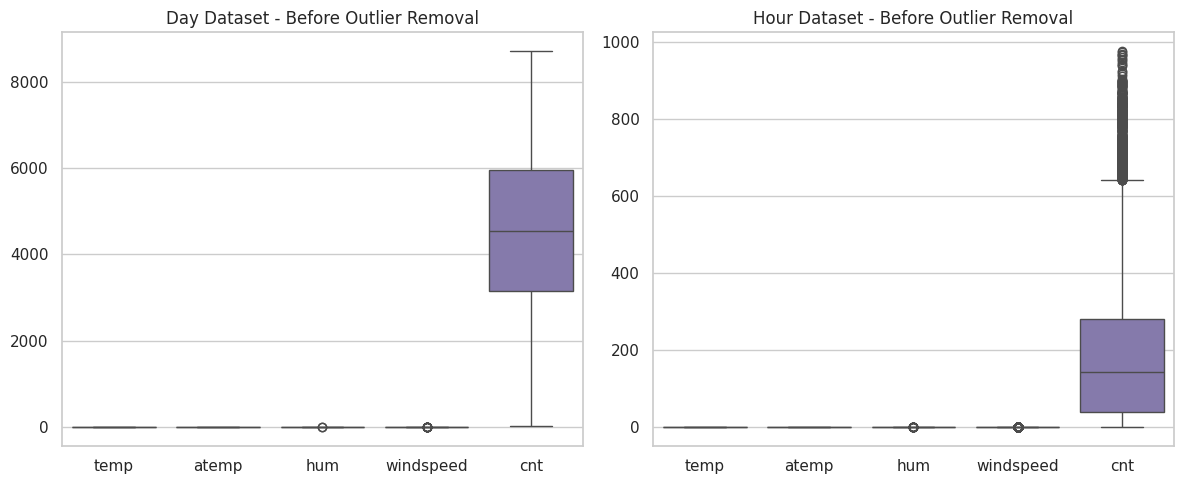

In [8]:
# TASK 4: Outlier Detection & Removal (IQR Method)

print("\n===== OUTLIER REMOVAL USING IQR =====")

# Select numeric columns
numeric_cols = ['temp','atemp','hum','windspeed','cnt']
numeric_day  = [c for c in numeric_cols if c in day_df.columns]
numeric_hour = [c for c in numeric_cols if c in hour_df.columns]

def remove_outliers(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    return df_clean

#Boxplot before removal
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=day_df[numeric_day])
plt.title("Day Dataset - Before Outlier Removal")

plt.subplot(1,2,2)
sns.boxplot(data=hour_df[numeric_hour])
plt.title("Hour Dataset - Before Outlier Removal")

plt.tight_layout()
plt.show()



Day dataset rows before: 731 | after: 717
Hour dataset rows before: 17379 | after: 16535


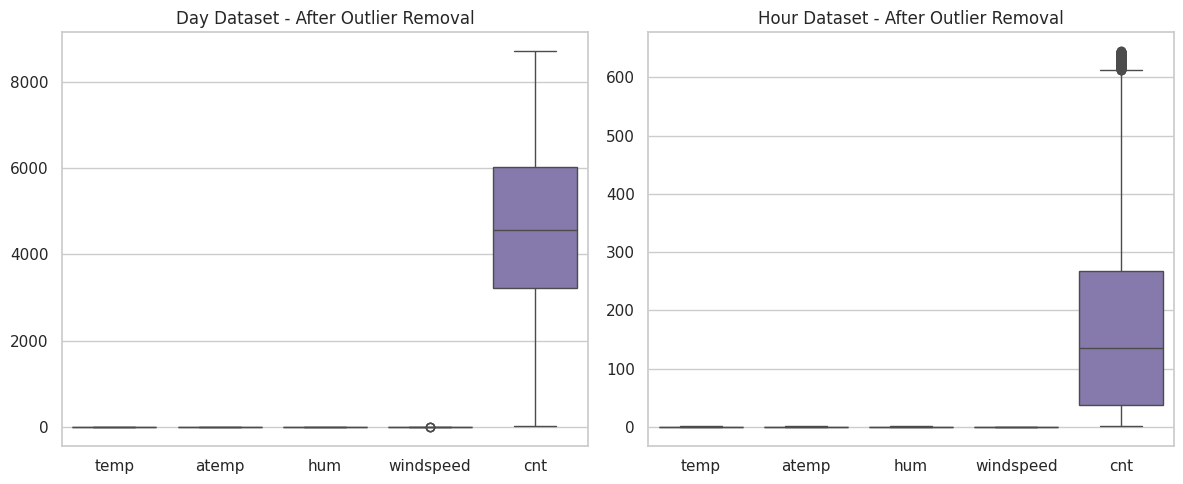


Outlier removal completed.


In [9]:
# Apply outlier removal
day_before = day_df.shape[0]
hour_before = hour_df.shape[0]

day_df = remove_outliers(day_df, numeric_day)
hour_df = remove_outliers(hour_df, numeric_hour)

day_after = day_df.shape[0]
hour_after = hour_df.shape[0]

print("\nDay dataset rows before:", day_before, "| after:", day_after)
print("Hour dataset rows before:", hour_before, "| after:", hour_after)

# Boxplot after removal
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=day_df[numeric_day])
plt.title("Day Dataset - After Outlier Removal")

plt.subplot(1,2,2)
sns.boxplot(data=hour_df[numeric_hour])
plt.title("Hour Dataset - After Outlier Removal")

plt.tight_layout()
plt.show()

print("\nOutlier removal completed.")

In [10]:
# TASK 5: MODEL TRAINING WEEK 3

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

#Day dataset

In [11]:
X_day = day_df.drop("cnt", axis=1)
y_day = day_df["cnt"]

# Train-test split
X_train_day, X_test_day, y_train_day, y_test_day = train_test_split(X_day, y_day, test_size=0.2, random_state=42)

print("Train shape:", X_train_day.shape)
print("Test shape:", X_test_day.shape)

# Scaling
scaler_day = StandardScaler()
X_train_day_scaled = scaler_day.fit_transform(X_train_day)
X_test_day_scaled = scaler_day.transform(X_test_day)

# Linear Regression
lr_day = LinearRegression()
lr_day.fit(X_train_day_scaled, y_train_day)
day_lr_pred = lr_day.predict(X_test_day_scaled)

print("\nDAY DATASET — Linear Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_test_day, day_lr_pred)))
print("MAE :", mean_absolute_error(y_test_day, day_lr_pred))
print("R² :", r2_score(y_test_day, day_lr_pred))

rf_day = RandomForestRegressor(n_estimators=200, random_state=42)
rf_day.fit(X_train_day, y_train_day)
day_rf_pred = rf_day.predict(X_test_day)

print("\nDAY DATASET — Random Forest")
print("RMSE:", np.sqrt(mean_squared_error(y_test_day, day_rf_pred)))
print("MAE :", mean_absolute_error(y_test_day, day_rf_pred))
print("R² :", r2_score(y_test_day, day_rf_pred))


Train shape: (573, 10)
Test shape: (144, 10)

DAY DATASET — Linear Regression
RMSE: 1270.8645153745356
MAE : 1075.671781912195
R² : 0.5711801210459297

DAY DATASET — Random Forest
RMSE: 1150.2214523436014
MAE : 968.1814930555556
R² : 0.6487314006748115


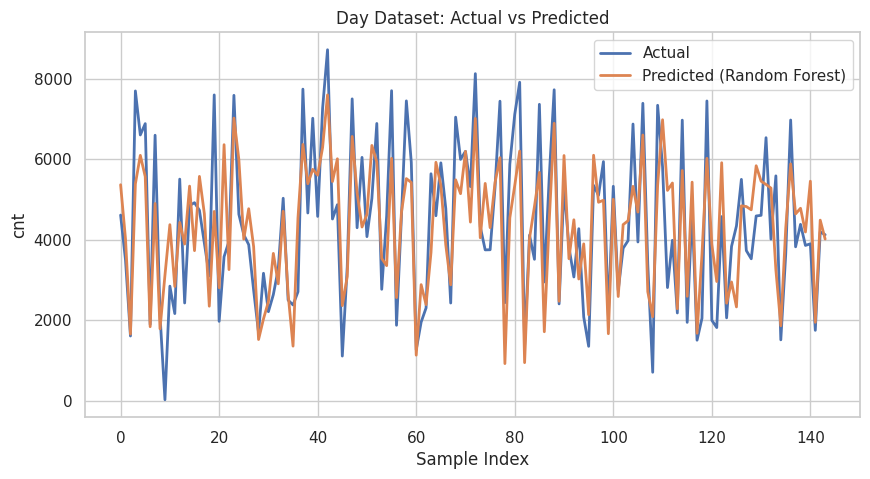

In [12]:
plt.figure(figsize=(10,5))
plt.plot(y_test_day.values, label="Actual", linewidth=2)
plt.plot(day_rf_pred, label="Predicted (Random Forest)", linewidth=2)
plt.title("Day Dataset: Actual vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("cnt")
plt.legend()
plt.show()


#Hour Dataset

In [13]:
X_hour = hour_df.drop("cnt", axis=1)
y_hour = hour_df["cnt"]

# Train-test split
X_train_hr, X_test_hr, y_train_hr, y_test_hr = train_test_split(
    X_hour, y_hour, test_size=0.2, random_state=42
)

print("Train shape:", X_train_hr.shape)
print("Test shape:", X_test_hr.shape)

# Scaling
scaler_hr = StandardScaler()
X_train_hr_scaled = scaler_hr.fit_transform(X_train_hr)
X_test_hr_scaled = scaler_hr.transform(X_test_hr)

# Linear Regression
lr_hour = LinearRegression()
lr_hour.fit(X_train_hr_scaled, y_train_hr)
hr_lr_pred = lr_hour.predict(X_test_hr_scaled)

print("\nHOUR DATASET — Linear Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_test_hr, hr_lr_pred)))
print("MAE :", mean_absolute_error(y_test_hr, hr_lr_pred))
print("R² :", r2_score(y_test_hr, hr_lr_pred))

# Random Forest
rf_hour = RandomForestRegressor(n_estimators=200, random_state=42)
rf_hour.fit(X_train_hr, y_train_hr)
hr_rf_pred = rf_hour.predict(X_test_hr)

print("\n HOUR DATASET — Random Forest")
print("RMSE:", np.sqrt(mean_squared_error(y_test_hr, hr_rf_pred)))
print("MAE :", mean_absolute_error(y_test_hr, hr_rf_pred))
print("R² :", r2_score(y_test_hr, hr_rf_pred))

Train shape: (13228, 11)
Test shape: (3307, 11)

HOUR DATASET — Linear Regression
RMSE: 120.7503321283933
MAE : 92.18121007563586
R² : 0.384399006940927

 HOUR DATASET — Random Forest
RMSE: 58.75337097683813
MAE : 39.05499051434907
R² : 0.8542568263103368


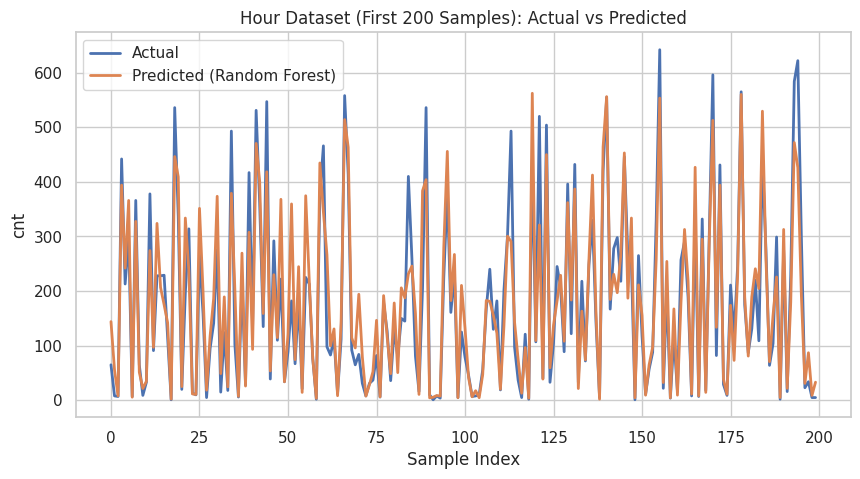

In [14]:
# Plot first 200 values for clarity
plt.figure(figsize=(10, 5))
plt.plot(y_test_hr.values[:200], label='Actual', linewidth=2)
plt.plot(hr_rf_pred[:200], label='Predicted (Random Forest)', linewidth=2)
plt.title("Hour Dataset (First 200 Samples): Actual vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("cnt")
plt.legend()
plt.show()


WEEK 4

In [15]:
# ====== Hyperparameter tuning imports ======
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from scipy.stats import randint, uniform
import joblib
import math
import matplotlib.pyplot as plt


Hour dataset

In [16]:
print("\n===== HYPERPARAMETER TUNING — HOUR DATASET =====")

from scipy.stats import randint

param_dist_hour_fast = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(5, 20),
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 8)
}

rf_tuner_hour_fast = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist_hour_fast,
    n_iter=5,
    cv=2,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

rf_tuner_hour_fast.fit(X_train_hr, y_train_hr)

best_hour_model_fast = rf_tuner_hour_fast.best_estimator_
hour_tuned_pred_fast = best_hour_model_fast.predict(X_test_hr)

print("\nBest Params (Hour):", rf_tuner_hour_fast.best_params_)
print("RMSE:", np.sqrt(mean_squared_error(y_test_hr, hour_tuned_pred_fast)))
print("MAE :", mean_absolute_error(y_test_hr, hour_tuned_pred_fast))
print("R²  :", r2_score(y_test_hr, hour_tuned_pred_fast))



===== HYPERPARAMETER TUNING — HOUR DATASET =====

Best Params (Hour): {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 174}
RMSE: 59.92006335031311
MAE : 40.82229433399207
R²  : 0.8484111802884958


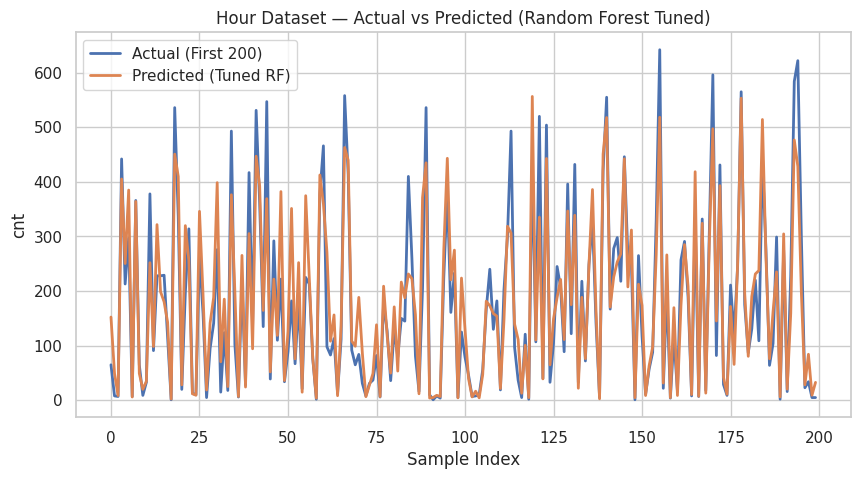

In [17]:
# ===== PLOT: Actual vs Predicted (Hour Dataset — Tuned RF) =====

plt.figure(figsize=(10,5))
plt.plot(y_test_hr.values[:200], label='Actual (First 200)', linewidth=2)
plt.plot(hour_tuned_pred_fast[:200], label='Predicted (Tuned RF)', linewidth=2)

plt.title("Hour Dataset — Actual vs Predicted (Random Forest Tuned)")
plt.xlabel("Sample Index")
plt.ylabel("cnt")
plt.legend()
plt.show()


In [18]:
print("\n===== HYPERPARAMETER TUNING — DAY DATASET =====")

param_dist_day = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(5, 30),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}

rf_tuner_day = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist_day,
    n_iter=20,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

rf_tuner_day.fit(X_train_day, y_train_day)

best_day_model = rf_tuner_day.best_estimator_
day_tuned_pred = best_day_model.predict(X_test_day)

print("\nBest Params (Day):", rf_tuner_day.best_params_)
print("RMSE:", np.sqrt(mean_squared_error(y_test_day, day_tuned_pred)))
print("MAE :", mean_absolute_error(y_test_day, day_tuned_pred))
print("R²  :", r2_score(y_test_day, day_tuned_pred))



===== HYPERPARAMETER TUNING — DAY DATASET =====

Best Params (Day): {'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 13, 'n_estimators': 413}
RMSE: 1142.441292239561
MAE : 963.1929865220258
R²  : 0.6534673288863597


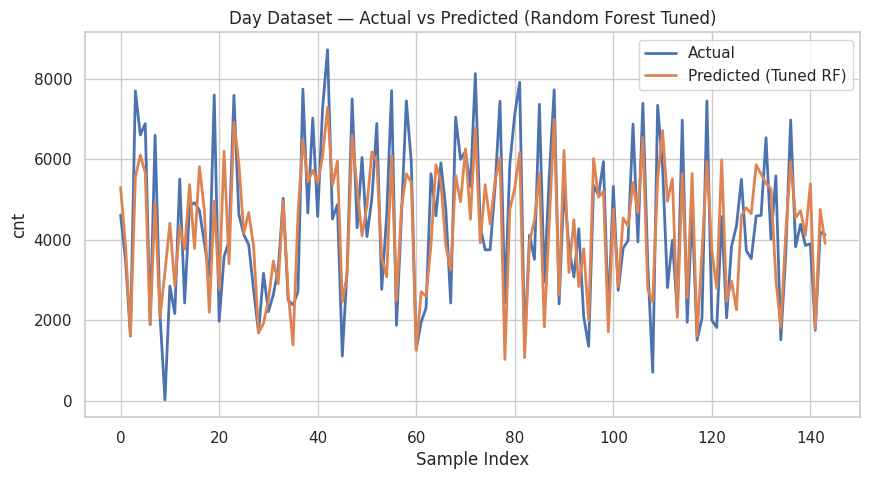

In [19]:
# ===== PLOT: Actual vs Predicted (Day Dataset — Tuned RF) =====

plt.figure(figsize=(10,5))
plt.plot(y_test_day.values, label='Actual', linewidth=2)
plt.plot(day_tuned_pred, label='Predicted (Tuned RF)', linewidth=2)

plt.title("Day Dataset — Actual vs Predicted (Random Forest Tuned)")
plt.xlabel("Sample Index")
plt.ylabel("cnt")
plt.legend()
plt.show()



===== XGBOOST + HYPERPARAMETER TUNING — HOUR DATASET =====

Best Params (XGB Hour): {'colsample_bytree': np.float64(0.7554709158757928), 'learning_rate': np.float64(0.09140470953216877), 'max_depth': 7, 'n_estimators': 379, 'subsample': np.float64(0.7427013306774357)}
RMSE: 53.61005355152031
MAE : 36.40232467651367
R²  : 0.8786569237709045


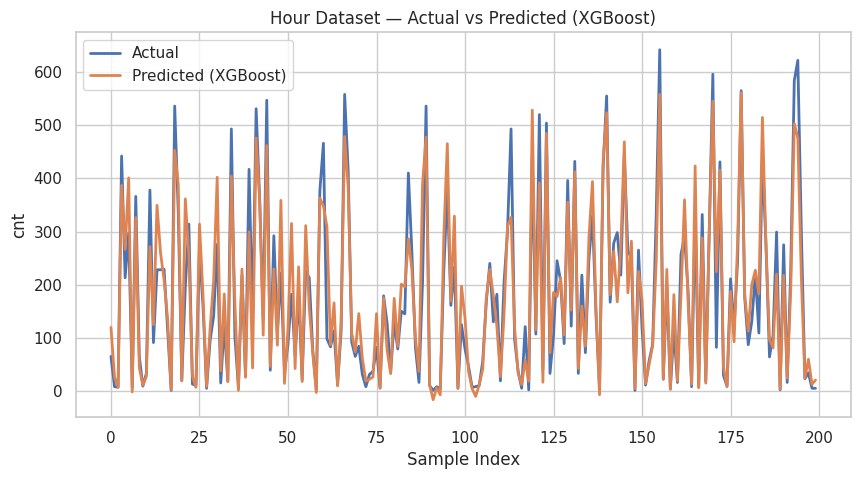

In [20]:
from xgboost import XGBRegressor
print("\n===== XGBOOST + HYPERPARAMETER TUNING — HOUR DATASET =====")

xgb_hour = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

param_dist_xgb_hour = {
    'n_estimators': randint(100, 500),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

xgb_tuner_hour = RandomizedSearchCV(
    xgb_hour,
    param_distributions=param_dist_xgb_hour,
    n_iter=20,
    cv=2,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

xgb_tuner_hour.fit(X_train_hr, y_train_hr)

best_xgb_hour = xgb_tuner_hour.best_estimator_
xgb_hour_pred = best_xgb_hour.predict(X_test_hr)

print("\nBest Params (XGB Hour):", xgb_tuner_hour.best_params_)
print("RMSE:", np.sqrt(mean_squared_error(y_test_hr, xgb_hour_pred)))
print("MAE :", mean_absolute_error(y_test_hr, xgb_hour_pred))
print("R²  :", r2_score(y_test_hr, xgb_hour_pred))
plt.figure(figsize=(10,5))
plt.plot(y_test_hr.values[:200], label='Actual', linewidth=2)
plt.plot(xgb_hour_pred[:200], label='Predicted (XGBoost)', linewidth=2)
plt.title("Hour Dataset — Actual vs Predicted (XGBoost)")
plt.xlabel("Sample Index")
plt.ylabel("cnt")
plt.legend()
plt.show()



===== XGBOOST + HYPERPARAMETER TUNING — DAY DATASET =====

Best Params (XGB Day): {'colsample_bytree': np.float64(0.8446612641953124), 'learning_rate': np.float64(0.012119891565915222), 'max_depth': 3, 'n_estimators': 660, 'subsample': np.float64(0.8099098641033556)}
RMSE: 1145.989419671927
MAE : 980.87109375
R²  : 0.6513115167617798


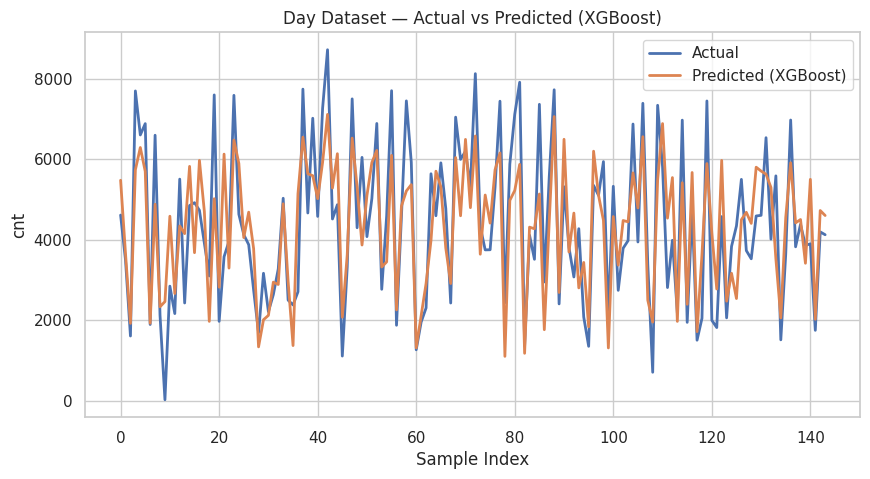

In [21]:
print("\n===== XGBOOST + HYPERPARAMETER TUNING — DAY DATASET =====")

xgb_day = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

param_dist_xgb_day = {
    'n_estimators': randint(100, 800),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

xgb_tuner_day = RandomizedSearchCV(
    xgb_day,
    param_distributions=param_dist_xgb_day,
    n_iter=30,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

xgb_tuner_day.fit(X_train_day, y_train_day)

best_xgb_day = xgb_tuner_day.best_estimator_
xgb_day_pred = best_xgb_day.predict(X_test_day)

print("\nBest Params (XGB Day):", xgb_tuner_day.best_params_)
print("RMSE:", np.sqrt(mean_squared_error(y_test_day, xgb_day_pred)))
print("MAE :", mean_absolute_error(y_test_day, xgb_day_pred))
print("R²  :", r2_score(y_test_day, xgb_day_pred))
plt.figure(figsize=(10,5))
plt.plot(y_test_day.values, label='Actual', linewidth=2)
plt.plot(xgb_day_pred, label='Predicted (XGBoost)', linewidth=2)
plt.title("Day Dataset — Actual vs Predicted (XGBoost)")
plt.xlabel("Sample Index")
plt.ylabel("cnt")
plt.legend()
plt.show()


In [22]:
print("\n===== XGBOOST (ADVANCED) — DAY DATASET =====")

xgb_day_adv = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

param_dist_xgb_day_adv = {
    'n_estimators': randint(800, 2000),        # MORE TREES
    'learning_rate': uniform(0.01, 0.1),       # SLOWER LEARNING
    'max_depth': randint(4, 12),
    'min_child_weight': randint(1, 10),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 5),                     # SPLIT REGULARIZATION
    'reg_alpha': uniform(0, 5),                 # L1
    'reg_lambda': uniform(1, 5)                 # L2
}

xgb_tuner_day_adv = RandomizedSearchCV(
    xgb_day_adv,
    param_distributions=param_dist_xgb_day_adv,
    n_iter=50,          # IMPORTANT
    cv=3,
    scoring='r2',       # DIRECTLY OPTIMIZE R²
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_tuner_day_adv.fit(X_train_day, y_train_day)

best_xgb_day_adv = xgb_tuner_day_adv.best_estimator_
xgb_day_pred_adv = best_xgb_day_adv.predict(X_test_day)

print("\nBest Params (XGB Day - Advanced):", xgb_tuner_day_adv.best_params_)
print("RMSE:", np.sqrt(mean_squared_error(y_test_day, xgb_day_pred_adv)))
print("MAE :", mean_absolute_error(y_test_day, xgb_day_pred_adv))
print("R²  :", r2_score(y_test_day, xgb_day_pred_adv))



===== XGBOOST (ADVANCED) — DAY DATASET =====
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best Params (XGB Day - Advanced): {'colsample_bytree': np.float64(0.8785217091359153), 'gamma': np.float64(3.56135294962221), 'learning_rate': np.float64(0.02480869299533999), 'max_depth': 11, 'min_child_weight': 1, 'n_estimators': 1498, 'reg_alpha': np.float64(3.047821669899484), 'reg_lambda': np.float64(3.5133951161443076), 'subsample': np.float64(0.7154436253749967)}
RMSE: 1184.0681462652392
MAE : 981.0294189453125
R²  : 0.6277542114257812


In [23]:
print("\n===== BASELINE XGBOOST — DAY =====")

xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_base.fit(X_train_day, y_train_day)
base_pred = xgb_base.predict(X_test_day)

print("RMSE:", np.sqrt(mean_squared_error(y_test_day, base_pred)))
print("MAE :", mean_absolute_error(y_test_day, base_pred))
print("R²  :", r2_score(y_test_day, base_pred))



===== BASELINE XGBOOST — DAY =====
RMSE: 1293.90875837518
MAE : 1062.1748046875
R²  : 0.5554877519607544


In [24]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import randint, uniform
# import numpy as np
# import math


In [25]:
print("\n===== GRID SEARCH — XGBOOST (DAY) =====")

param_grid = {
    'n_estimators': [300, 600],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.7, 0.9]
}

grid_xgb = GridSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_xgb.fit(X_train_day, y_train_day)
grid_pred = grid_xgb.best_estimator_.predict(X_test_day)

print("Best Params:", grid_xgb.best_params_)
print("R²:", r2_score(y_test_day, grid_pred))



===== GRID SEARCH — XGBOOST (DAY) =====
Best Params: {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.7}
R²: 0.6345392465591431


In [26]:
print("\n===== RANDOMIZED SEARCH — XGBOOST (DAY) =====")

rand_xgb = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1),
    param_distributions={
        'n_estimators': randint(300, 1500),
        'max_depth': randint(4, 12),
        'learning_rate': uniform(0.01, 0.1),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4)
    },
    n_iter=30,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

rand_xgb.fit(X_train_day, y_train_day)
rand_pred = rand_xgb.best_estimator_.predict(X_test_day)

print("Best Params:", rand_xgb.best_params_)
print("R²:", r2_score(y_test_day, rand_pred))



===== RANDOMIZED SEARCH — XGBOOST (DAY) =====
Best Params: {'colsample_bytree': np.float64(0.8446612641953124), 'learning_rate': np.float64(0.01070663052197174), 'max_depth': 4, 'n_estimators': 774, 'subsample': np.float64(0.8447411578889518)}
R²: 0.645512580871582


In [27]:
print("\n===== MANUAL TUNING — XGBOOST (DAY) =====")

xgb_manual = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=2,
    reg_lambda=3,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_manual.fit(X_train_day, y_train_day)
manual_pred = xgb_manual.predict(X_test_day)

print("R²:", r2_score(y_test_day, manual_pred))



===== MANUAL TUNING — XGBOOST (DAY) =====
R²: 0.6113327741622925


In [28]:
import xgboost as xgb

print("\n===== XGBOOST WITH EARLY STOPPING — DAY (NATIVE API) =====")

# Convert data to DMatrix (XGBoost format)
dtrain_day = xgb.DMatrix(X_train_day, label=y_train_day)
dtest_day  = xgb.DMatrix(X_test_day, label=y_test_day)

params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.02,
    'max_depth': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

# Train with early stopping
xgb_native_day = xgb.train(
    params=params,
    dtrain=dtrain_day,
    num_boost_round=3000,
    evals=[(dtrain_day, 'train'), (dtest_day, 'eval')],
    early_stopping_rounds=50,
    verbose_eval=False
)

# Predictions
xgb_day_pred_native = xgb_native_day.predict(dtest_day)

print("RMSE:", np.sqrt(mean_squared_error(y_test_day, xgb_day_pred_native)))
print("MAE :", mean_absolute_error(y_test_day, xgb_day_pred_native))
print("R²  :", r2_score(y_test_day, xgb_day_pred_native))



===== XGBOOST WITH EARLY STOPPING — DAY (NATIVE API) =====
RMSE: 1201.5885319026643
MAE : 1000.1258544921875
R²  : 0.6166566014289856


In [29]:
results = {
    "Baseline XGB"   : r2_score(y_test_day, base_pred),
    "Grid Search"    : r2_score(y_test_day, grid_pred),
    "Random Search"  : r2_score(y_test_day, rand_pred),
    "Manual Tuning"  : r2_score(y_test_day, manual_pred),
    "Early Stopping" : r2_score(y_test_day, xgb_day_pred_native)
}

print("\n===== FINAL R² COMPARISON =====")
for k, v in results.items():
    print(f"{k:<20} : {round(v, 4)}")



===== FINAL R² COMPARISON =====
Baseline XGB         : 0.5555
Grid Search          : 0.6345
Random Search        : 0.6455
Manual Tuning        : 0.6113
Early Stopping       : 0.6167


In [30]:
print("\n===== DAY DATASET: RF vs XGB (TRAIN vs TEST R²) =====")

# ---------- Random Forest (Tuned) ----------
rf_day_train_pred = best_day_model.predict(X_train_day)
rf_day_test_pred  = day_tuned_pred

rf_day_train_r2 = r2_score(y_train_day, rf_day_train_pred)
rf_day_test_r2  = r2_score(y_test_day, rf_day_test_pred)

print("\nRandom Forest (Day)")
print("Train R²:", round(rf_day_train_r2, 4))
print("Test  R²:", round(rf_day_test_r2, 4))

xgb_day_train_pred = xgb_native_day.predict(xgb.DMatrix(X_train_day))
xgb_day_test_pred  = xgb_day_pred_native

xgb_day_train_r2 = r2_score(y_train_day, xgb_day_train_pred)
xgb_day_test_r2  = r2_score(y_test_day, xgb_day_test_pred)

print("\nXGBoost (Day)")
print("Train R²:", round(xgb_day_train_r2, 4))
print("Test  R²:", round(xgb_day_test_r2, 4))



===== DAY DATASET: RF vs XGB (TRAIN vs TEST R²) =====

Random Forest (Day)
Train R²: 0.8386
Test  R²: 0.6535

XGBoost (Day)
Train R²: 0.986
Test  R²: 0.6167


In [31]:
print("\n===== HOUR DATASET: RF vs XGB (TRAIN vs TEST R²) =====")

# ---------- Random Forest (Tuned) ----------
rf_hour_train_pred = best_hour_model_fast.predict(X_train_hr)
rf_hour_test_pred  = hour_tuned_pred_fast

rf_hour_train_r2 = r2_score(y_train_hr, rf_hour_train_pred)
rf_hour_test_r2  = r2_score(y_test_hr, rf_hour_test_pred)

print("\nRandom Forest (Hour)")
print("Train R²:", round(rf_hour_train_r2, 4))
print("Test  R²:", round(rf_hour_test_r2, 4))


# ---------- XGBoost (Tuned sklearn model) ----------
xgb_hour_train_pred = best_xgb_hour.predict(X_train_hr)
xgb_hour_test_pred  = xgb_hour_pred

xgb_hour_train_r2 = r2_score(y_train_hr, xgb_hour_train_pred)
xgb_hour_test_r2  = r2_score(y_test_hr, xgb_hour_test_pred)

print("\nXGBoost (Hour)")
print("Train R²:", round(xgb_hour_train_r2, 4))
print("Test  R²:", round(xgb_hour_test_r2, 4))



===== HOUR DATASET: RF vs XGB (TRAIN vs TEST R²) =====

Random Forest (Hour)
Train R²: 0.9228
Test  R²: 0.8484

XGBoost (Hour)
Train R²: 0.9673
Test  R²: 0.8787


#prediction

In [40]:
# ===== USER INPUT FOR HOUR DATASET =====
hour_input = {
    'season': 2,
    'mnth': 6,
    'hr': 10,
    'holiday': 0,
    'weekday': 2,
    'workingday': 1,
    'weathersit': 1,
    'temp': 0.6,
    'atemp': 0.58,
    'hum': 0.4,
    'windspeed': 0.2
}
print("\n===== HOUR DATASET PREDICTION (hour → hour+6) =====")

hour_preds = []

for i in range(7):
    temp_input = hour_input.copy()
    temp_input['hr'] = hour_input['hr'] + i  # increment hour

    input_df = pd.DataFrame([temp_input])
    pred = best_xgb_hour.predict(input_df)[0]

    hour_preds.append(pred)
    print(f"Hour + {i} (hr={temp_input['hr']}): {int(pred)}")



===== HOUR DATASET PREDICTION (hour → hour+6) =====
Hour + 0 (hr=10): 185
Hour + 1 (hr=11): 223
Hour + 2 (hr=12): 282
Hour + 3 (hr=13): 296
Hour + 4 (hr=14): 266
Hour + 5 (hr=15): 282
Hour + 6 (hr=16): 411


In [38]:
# ===== USER INPUT FOR DAY DATASET =====
day_input = {
    'season': 2,
    'mnth': 6,
    'holiday': 0,
    'weekday': 2,
    'workingday': 1,
    'weathersit': 1,
    'temp': 0.6,
    'atemp': 0.58,
    'hum': 0.4,
    'windspeed': 0.2
}
print("\n===== DAY DATASET PREDICTION (day → day+6) =====")

day_preds = []

for i in range(7):
    temp_input = day_input.copy()
    temp_input['weekday'] = (day_input['weekday'] + i) % 7

    input_df = pd.DataFrame([temp_input])
    pred = best_day_model.predict(input_df)[0]

    day_preds.append(pred)
    print(f"Day + {i} (weekday={temp_input['weekday']}): {int(pred)}")



===== DAY DATASET PREDICTION (day → day+6) =====
Day + 0 (weekday=2): 6335
Day + 1 (weekday=3): 6318
Day + 2 (weekday=4): 6318
Day + 3 (weekday=5): 6418
Day + 4 (weekday=6): 6510
Day + 5 (weekday=0): 6407
Day + 6 (weekday=1): 6380


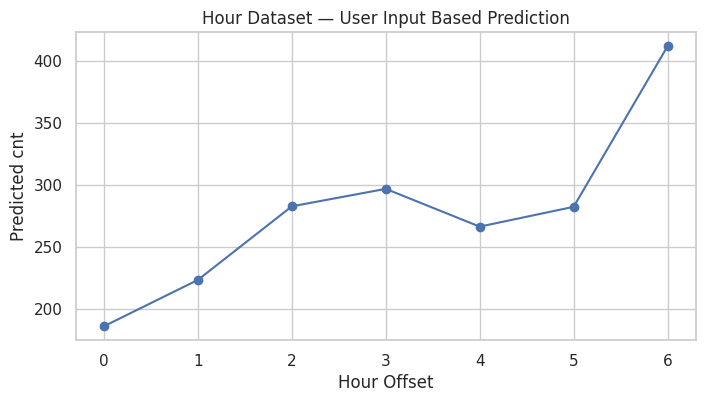

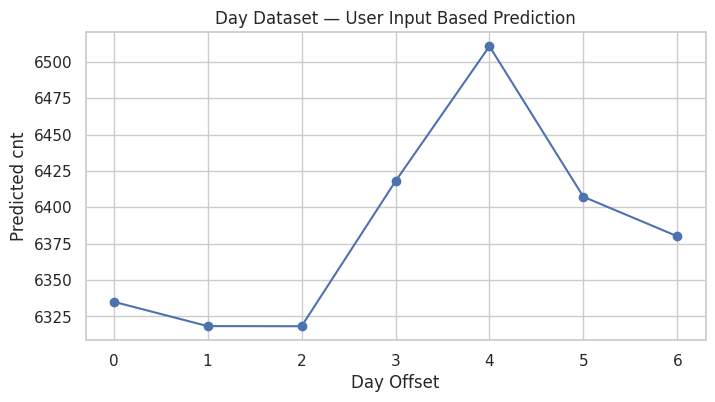

In [39]:
plt.figure(figsize=(8,4))
plt.plot(hour_preds, marker='o')
plt.title("Hour Dataset — User Input Based Prediction")
plt.xlabel("Hour Offset")
plt.ylabel("Predicted cnt")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(day_preds, marker='o')
plt.title("Day Dataset — User Input Based Prediction")
plt.xlabel("Day Offset")
plt.ylabel("Predicted cnt")
plt.show()
